# Simple Linear Regression

Regresi linear sederhana berfungsi untuk mengetahui hubungan sebab akibat atau mengetahui pengaruh variabel faktor penyebab (X) terhadap variabel akibatnya (Y).

## 1 Import Libraries and Data

Pada studi kasus simple linear regression menggunakan data dengan variabel independen (X) yaitu Sr dan variabel dependen Aroma. Pada studi kasus kali ini, ingin diketahui sejauh mana pengaruh konsentrasi Strontium (Sr) terhadap rating Aroma?

variabel independen (X) = Sr, menyatakan besarnya konsentrasi bahan Strontium (Sr).<br>
variable dependen (y) = Aroma, rating aroma. <br>

In [ ]:
# connect colab ke g drive
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
# Load library/package
import os
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from scipy.stats import shapiro

# Sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Statmodels
import statsmodels
import statsmodels.api as sm

In [ ]:
path = '/content/gdrive/MyDrive/PKKM KA/Day 2/Supervised/Dataset/'

In [ ]:
os.listdir(path)

['house_prices.csv',
 'Data wine aroma.csv',
 'loan_prediction.csv',
 'TelcoChurn.csv']

In [ ]:
df = pd.read_csv(path+ "Data wine aroma.csv")

## 2 Exploratory Data Analysis (EDA) & Data Pre-Processing

### Summary Data

In [ ]:
df.describe()

,Cd,Mo,Mn,Ni,Cu,Al,Ba,Cr,Sr,Pb,B,Mg,Si,Na,Ca,P,K,Aroma
count,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000
mean,0.053805,0.177366,1.646220,0.102024,0.170610,0.925317,0.216293,0.042390,0.800512,0.864146,4.820000,124.107317,14.318537,39.013659,76.502439,153.817073,1099.536585,4.924390
std,0.023502,0.095534,0.601835,0.082417,0.188871,0.470496,0.106508,0.018888,0.445945,0.458837,1.614542,29.912200,8.603771,29.603790,18.622882,28.261369,193.709589,1.023177
min,0.005000,0.009000,0.906000,0.041000,0.038000,0.308000,0.070000,0.006000,0.156000,0.025000,2.000000,75.900000,4.570000,7.250000,44.900000,81.900000,810.000000,3.300000
25%,0.039000,0.126000,1.250000,0.061000,0.058000,0.596000,0.105000,0.028000,0.360000,0.561000,3.370000,99.300000,7.620000,12.500000,64.400000,133.000000,976.000000,4.300000
50%,0.058000,0.166000,1.610000,0.073000,0.099000,0.811000,0.225000,0.038000,0.898000,0.777000,4.570000,125.000000,13.400000,35.400000,70.600000,156.000000,1090.000000,5.000000
75%,0.067000,0.234000,1.760000,0.112000,0.171000,1.210000,0.299000,0.053000,1.120000,1.190000,6.210000,143.000000,17.800000,55.200000,85.900000,172.000000,1200.000000,5.500000
max,0.106000,0.479000,4.080000,0.466000,0.830000,2.070000,0.408000,0.100000,2.140000,2.060000,8.110000,199.000000,43.600000,125.000000,128.000000,218.000000,1810.000000,7.700000


### Missing Value

Missing value adalah data yang hilang, atau nilai yang hilang, terjadi ketika tidak ada nilai data yang disimpan untuk variabel dalam pengamatan. Kita ingin melakukan identifikasi, apakah terdapat data yang missing atau tidak dalam observasi pengamatan.

In [ ]:
df.isnull().sum()

,0
Cd,0
Mo,0
Mn,0
Ni,0
Cu,0
Al,0
Ba,0
Cr,0
Sr,0
Pb,0


### Duplicated Data

Melakukan identifikasi, apakah terdapat data/observasi yang sama atau tidak, apabila ada data yang terduplikasi maka data duplikasi harus dihapus.

In [ ]:
df.duplicated().sum()

3

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(38, 18)

### Adjusting the type of variable

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, 0 to 40
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Cd      38 non-null     float64
 1   Mo      38 non-null     float64
 2   Mn      38 non-null     float64
 3   Ni      38 non-null     float64
 4   Cu      38 non-null     float64
 5   Al      38 non-null     float64
 6   Ba      38 non-null     float64
 7   Cr      38 non-null     float64
 8   Sr      38 non-null     float64
 9   Pb      38 non-null     float64
 10  B       38 non-null     float64
 11  Mg      38 non-null     float64
 12  Si      38 non-null     float64
 13  Na      38 non-null     float64
 14  Ca      38 non-null     float64
 15  P       38 non-null     float64
 16  K       38 non-null     int64  
 17  Aroma   38 non-null     float64
dtypes: float64(17), int64(1)
memory usage: 5.6 KB


### Uji Asumsi sebelum Pemodelan Regresi Linier Sederhana

Asumsi yang perlu dipenuhi sebelum dilakukannya pemodelan regresi linier sederhana yaitu data berdistribusi normal (normalitas data) dan hubungan linier antara variabel prediktor (independen) dan variabel respon (dependen), karena variabel prediktornya ada 1 variabel maka tidak perlu uji asumsi gejala multikolinieritas.

Uji Normalitas adalah uji statistik yang dilakukan untuk mengetahui bagaimana sebaran sebuah data. Uji Normalitas data perlu dilakukan juga untuk mengetahui keberadaan ourlier (data pencilan) dan normalitas data variabel respon (dependen) agar bisa diatasi.

#### Uji Nomalitas Data

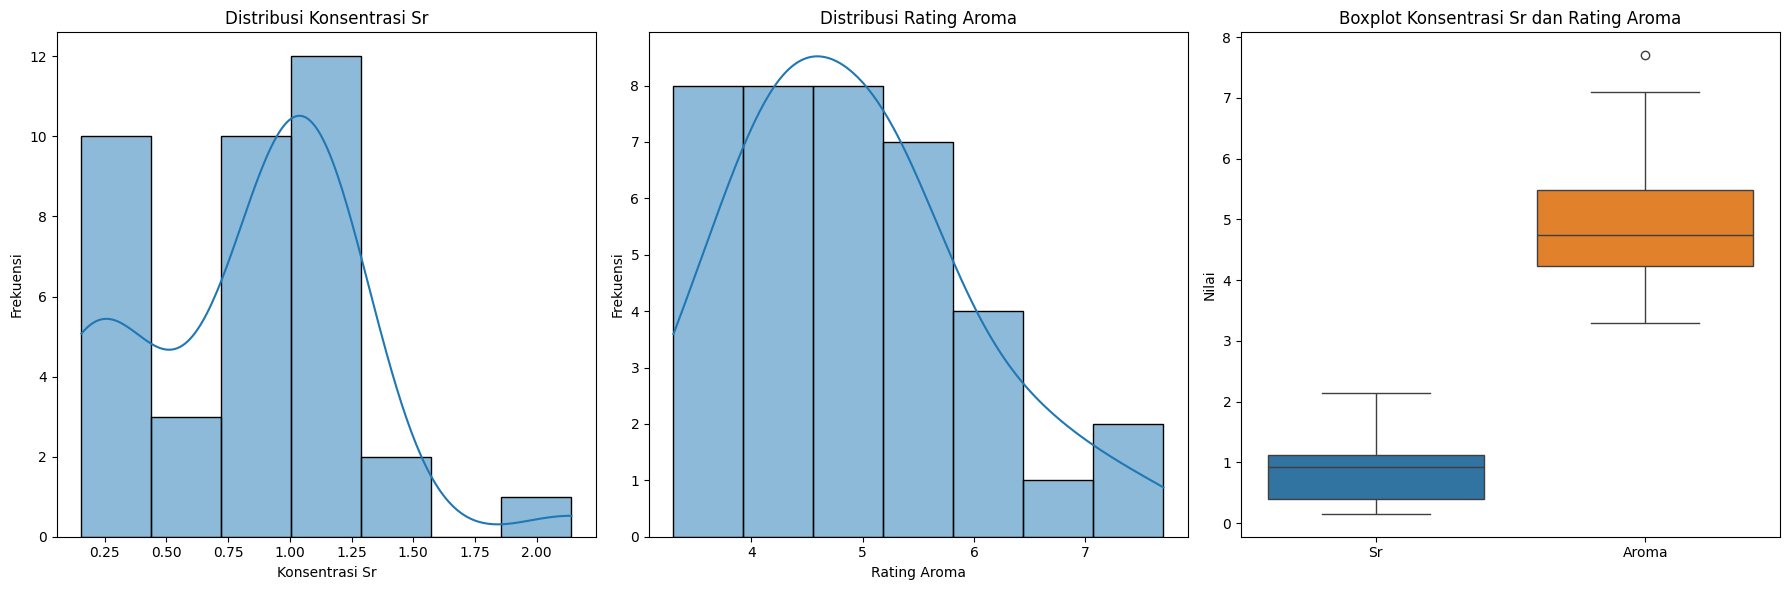

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menyiapkan subplots untuk 3 visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Histogram untuk 'Sr' (konsentrasi Strontium)
sns.histplot(df['Sr'], kde=True, ax=axes[0])
axes[0].set_title('Distribusi Konsentrasi Sr')
axes[0].set_xlabel('Konsentrasi Sr')
axes[0].set_ylabel('Frekuensi')

# Histogram untuk 'Aroma' (rating Aroma)
sns.histplot(df['Aroma'], kde=True, ax=axes[1])
axes[1].set_title('Distribusi Rating Aroma')
axes[1].set_xlabel('Rating Aroma')
axes[1].set_ylabel('Frekuensi')

# Boxplot untuk melihat penyebaran data dan outliers
sns.boxplot(data=df[['Sr', 'Aroma']], ax=axes[2])
axes[2].set_title('Boxplot Konsentrasi Sr dan Rating Aroma')
axes[2].set_ylabel('Nilai')

# Menampilkan plot
plt.tight_layout()
plt.show()


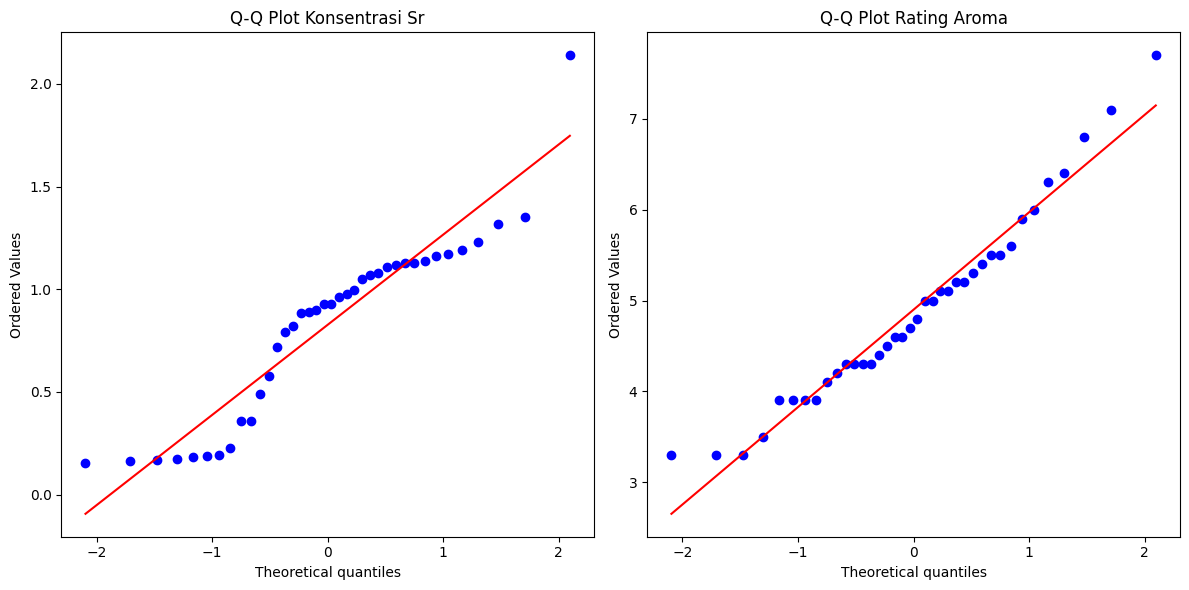

In [ ]:
import numpy as np
import scipy.stats as stats

# Q-Q Plot untuk 'Sr' (konsentrasi Strontium)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
stats.probplot(df['Sr'], dist="norm", plot=plt)
plt.title('Q-Q Plot Konsentrasi Sr')

# Q-Q Plot untuk 'Aroma' (rating Aroma)
plt.subplot(1, 2, 2)
stats.probplot(df['Aroma'], dist="norm", plot=plt)
plt.title('Q-Q Plot Rating Aroma')

plt.tight_layout()
plt.show()


> Insight Grafik:
*   Histogram
*   Boxplot
*   Q-Q Plot

Pengecekan normalitas data secara visual tidak dapat ditarik kesimpulan sehingga perlu dilakukan pengujian hipotesis berikut:
<br>
<br>
Ho: Data berdistribusi Normal <br>
H1: Data tidak berdistribusi Normal
<br>
<br>
Bila p-value kurang dari 0.05 maka Ho Ditolak, berarti Data tidak berdistribusi Normal
Bila p-value lebih dari 0.05 maka Ho Diterima, berarti Data berdistribusi Normal.
<br>
<br>
Salah satu Uji Distribusi Normalitas Data yaitu Uji Shapiro-Wilk.

In [ ]:
# Uji Shapiro-Wilk
from scipy.stats import shapiro

columns_to_check = ['Sr', 'Aroma']


for col in columns_to_check:
    stat, p = shapiro(df[col])  # Uji Shapiro-Wilk untuk kolom
    print(f'Pengujian Normalitas untuk {col}:')
    print(f'Statistik= {stat:.3f}, p-value = {p:.3f}')

    # Pengujian Hipotesis
    alpha = 0.05  # Level signifikansi
    if p > alpha:
        print(f'Gagal Tolak H0, {col} berdistribusi normal')
    else:
        print(f'Tolak H0, {col} tidak berdistribusi normal')
    print('-' * 50)

Pengujian Normalitas untuk Sr:
Statistik= 0.900, p-value = 0.003
Tolak H0, Sr tidak berdistribusi normal
--------------------------------------------------
Pengujian Normalitas untuk Aroma:
Statistik= 0.959, p-value = 0.182
Gagal Tolak H0, Aroma berdistribusi normal
--------------------------------------------------


> Hasil pengujian menunjukkan bahwa ....

> Karena data outliers sedikit dan tidak mempengaruhi normalitas data, kita dapat mengabaikannya. Tetapi apabila normalitas data dipengaruhi oleh adanya outliers maka dapat dilakukan trimming/penghapusan data outliers, menambah data observasi, atau menggunakan metode Robust Regression. Selain itu, data outliers ini dalam pengaplikasian yang sesungguhnya perlu dianalisis ulang untuk dicari tau karakteristiknya lebih dalam.

#### Uji Linearitas Data

Uji Linearitas adalah sifat hubungan yang linear antara variabel, artinya setiap perubahan yang terjadi pada satu variabel akan diikuti perubahan dengan besaran yang sejajar pada variabel lainnya.

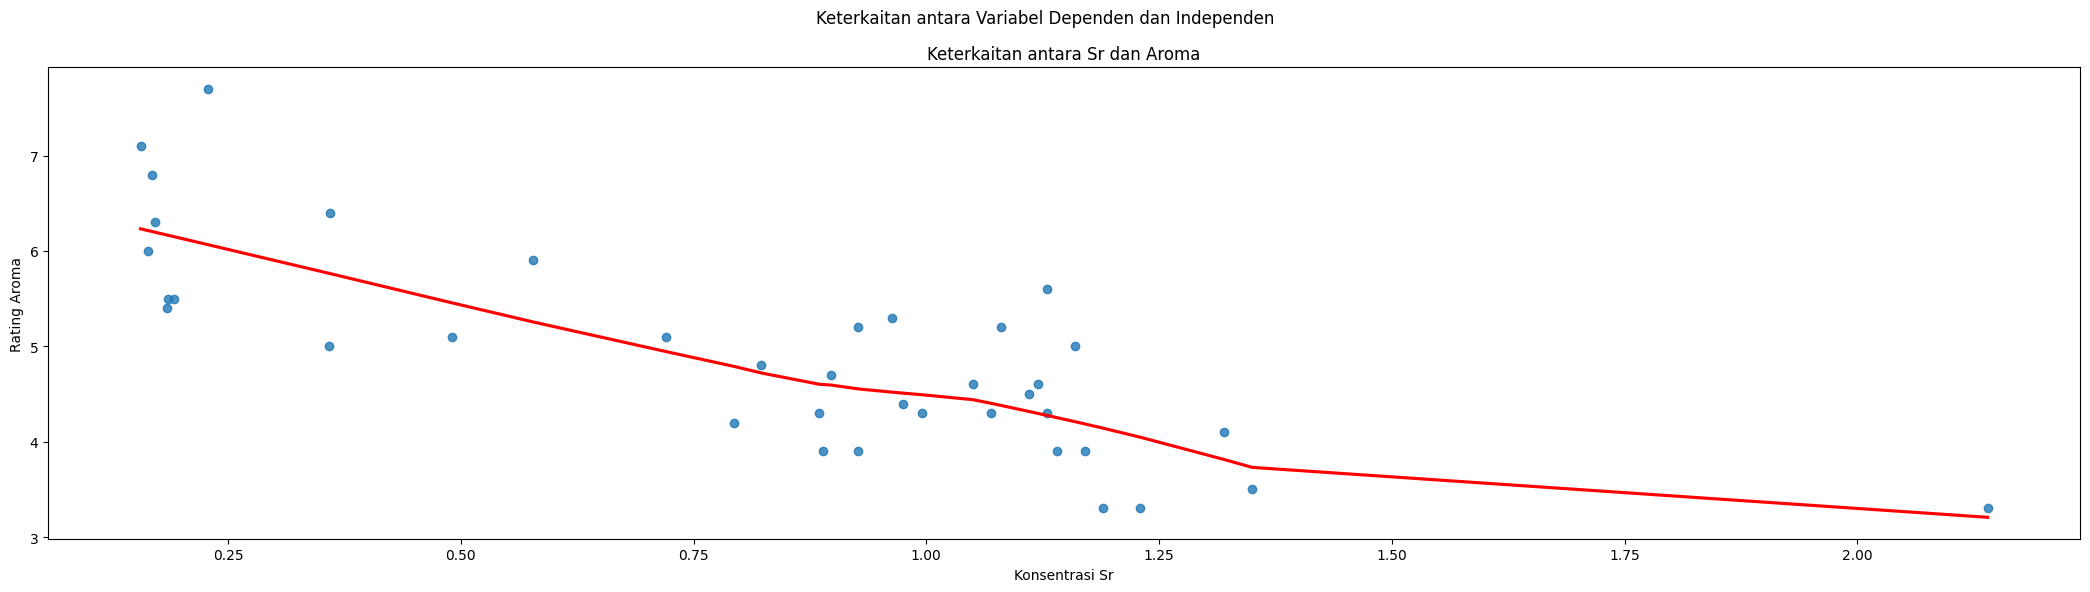

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(21, 6))
fig.suptitle('Keterkaitan antara Variabel Dependen dan Independen')

# Regplot untuk 'Sr' vs 'Aroma'
sns.regplot(x=df["Sr"], y=df["Aroma"], lowess=True, line_kws={'color': 'red'}, ax=ax)
ax.set_title('Keterkaitan antara Sr dan Aroma')
ax.set_xlabel('Konsentrasi Sr')
ax.set_ylabel('Rating Aroma')

# Menampilkan plot
plt.tight_layout()
plt.show()

## 3 Membangun Model Regresi

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Membangun Model dengan Sklearn

In [ ]:
# Misalkan 'data' adalah DataFrame yang memiliki kolom 'Sr' dan 'Aroma'
X = df[['Sr']]  # Variabel independen
y = df['Aroma']  # Variabel dependen

# Membagi data menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Membangun model regresi linear
model = LinearRegression()
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 0.590303319734953
R-squared: -0.14622003832029695


#### Asumsi Analisis Regresi

Uji Asumsi klasik adalah analisis yang dilakukan untuk menilai apakah di dalam sebuah model regresi linear Ordinary Least Square (OLS) terdapat masalah-masalah asumsi klasik.

**Asumsi Residual Distribusi Normal**

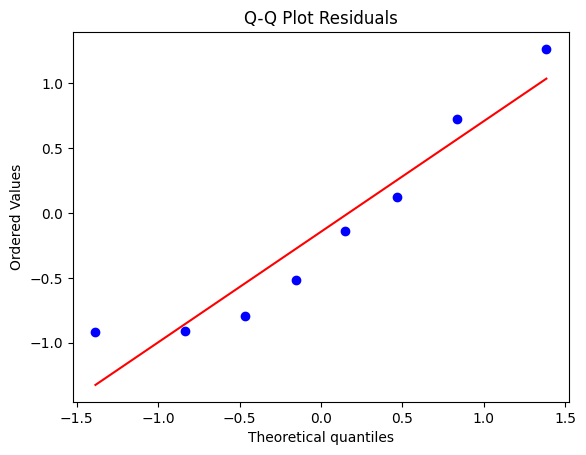

Shapiro-Wilk Test: Statistics=0.895, p-value=0.261


In [ ]:
# Menghitung residuals
residuals = y_test - y_pred

# Visualisasi Residuals menggunakan Q-Q Plot
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot Residuals')
plt.show()

# Uji Normalitas dengan Shapiro-Wilk
stat, p = shapiro(residuals)
print(f"Shapiro-Wilk Test: Statistics={stat:.3f}, p-value={p:.3f}")

**Asumsi No autokorelasi**


Uji Durbin watson akan menghasilkan nilai Durbin Watson (DW) yang nantinya akan dibandingkan dengan dua (2) nilai Durbin Watson Tabel, yaitu Durbin Upper (DU) dan Durbin Lower DL). Dikatakan tidak terdapat autokorelasi jika nilai DW > DU dan (4-DW) > DU atau bisa dinotasikan juga sebagai berikut: (4-DW) > DU < DW.


In [ ]:
from statsmodels.stats.stattools import durbin_watson

# Menghitung Durbin-Watson
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson Statistic: {dw_stat:.3f}")

Durbin-Watson Statistic: 1.396


**Asumsi Homoskedastisitas**

Uji Homoskedastisiitas untuk melihat apakah terdapat ketidaksamaan varians dari residual satu ke pengamatan ke pengamatan yang lain.


In [ ]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Menambah konstanta untuk intercept
X_train_const = sm.add_constant(X_train)

# Fit model OLS
model_ols = sm.OLS(y_train, X_train_const).fit()

# Uji Breusch-Pagan untuk Homoskedastisitas
bp_test = het_breuschpagan(model_ols.resid, model_ols.model.exog)
print(f"Breusch-Pagan Test p-value: {bp_test[1]:.3f}")

Breusch-Pagan Test p-value: 0.327


#### Evaluasi Model

In [ ]:
import statsmodels.api as sm

X_const = sm.add_constant(X)

model_stats = sm.OLS(y, X_const).fit()

print(model_stats.summary())

                            OLS Regression Results                            
Dep. Variable:                  Aroma   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     59.77
Date:                Thu, 14 Nov 2024   Prob (F-statistic):           3.70e-09
Time:                        03:48:13   Log-Likelihood:                -36.986
No. Observations:                  38   AIC:                             77.97
Df Residuals:                      36   BIC:                             81.25
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.4413      0.226     28.483      0.0

### Membangun model dengan package Statsmodels

In [ ]:
import statsmodels.api as sm

X_const = sm.add_constant(X)

model_stats = sm.OLS(y, X_const).fit()

print(model_stats.summary())

                            OLS Regression Results                            
Dep. Variable:                  Aroma   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     59.77
Date:                Thu, 14 Nov 2024   Prob (F-statistic):           3.70e-09
Time:                        03:48:20   Log-Likelihood:                -36.986
No. Observations:                  38   AIC:                             77.97
Df Residuals:                      36   BIC:                             81.25
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.4413      0.226     28.483      0.0

### Uji Partial & Serentak Analisis Regresi

Uji Parameter T-test  memiliki tujuan, apakah variabel independent(X) memberikan pengaruh secara partial terhadap variabel dependent (Y)

In [ ]:
print("Nilai p untuk T-test (Partial):")
print(model_stats.pvalues)

Nilai p untuk T-test (Partial):
const    2.745731e-26
Sr       3.700067e-09
dtype: float64


Uji kelayakan model F-test memilki tujuan, apakah model yang dibentuk layak digunakan atau tidak

In [ ]:
print("Nilai F-statistik:", model_stats.fvalue)
print("Nilai p untuk F-test:", model_stats.f_pvalue)

Nilai F-statistik: 59.76526322065298
Nilai p untuk F-test: 3.7000669550200283e-09
